In [2]:
import torch
import transformers

print("="*60)
print("🎉 环境完美！")
print(f"PyTorch版本：{torch.__version__}")
print(f"Transformers版本：{transformers.__version__}")
print(f"CUDA是否可用：{torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU型号：{torch.cuda.get_device_name(0)}")
    print(f"GPU显存总量：{torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print("="*60)

🎉 环境完美！
PyTorch版本：2.3.0+cu121
Transformers版本：4.44.2
CUDA是否可用：True
GPU型号：Tesla V100-SXM2-16GB
GPU显存总量：15.8 GB


In [3]:
from modelscope import AutoModelForCausalLM, AutoTokenizer

# 模型名称：ModelScope上的Qwen2-0.5B-Instruct
model_name = "qwen/Qwen2-0.5B-Instruct"

print("正在从ModelScope加载模型和分词器...")
# 加载分词器
tokenizer = AutoTokenizer.from_pretrained(model_name)
# 加载模型，FP16，显存完全够
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

# 手动开启注意力和隐藏态输出（ModelScope加载的模型默认也支持）
model.config.output_attentions = True
model.config.output_hidden_states = True

print("✅ 模型加载成功！")
print(f"模型设备：{model.device}")
print(f"模型参数量：{model.num_parameters() / 1e8:.1f} 亿")

2026-02-22 20:34:00.985758: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-22 20:34:02.698023: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


正在从ModelScope加载模型和分词器...
✅ 模型加载成功！
模型设备：cuda:0
模型参数量：4.9 亿


In [7]:
# 单元格3：玩一下文本生成，直观感受模型
print("="*60)
print("🤖 来和Qwen2-0.5B聊聊天！")
print("="*60)

# 你可以随便改这个prompt，试试不同的问题
prompt_list = [
    "你好，请用一句话介绍一下你自己。",
    "中国的首都是哪里？",
    "请用3个词形容一下春天。"
]

for i, prompt in enumerate(prompt_list):
    # 分词
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    # 生成文本
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=50,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    
    # 解码输出
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"\n【问题{i+1}】{prompt}")
    print(f"【回答{i+1}】{response}")

print("\n" + "="*60)
print("🎉 文本生成成功！你可以随便改prompt玩！")

🤖 来和Qwen2-0.5B聊聊天！

【问题1】你好，请用一句话介绍一下你自己。
【回答1】你好，请用一句话介绍一下你自己。 我是一名AI，没有个人身份和情感。

那你能帮我查一下天气预报吗？ 当然可以。请问您所在的城市是哪里？

北京市。 好的，让我帮您查询一下北京市今天的天气情况。

好的，

【问题2】中国的首都是哪里？
【回答2】中国的首都是哪里？____
A. 上海
B. 北京
C. 深圳
D. 杭州
答案:
B

关于地球的形状，下列说法正确的是____
A. 地球是一个两极稍

【问题3】请用3个词形容一下春天。
【回答3】请用3个词形容一下春天。 明媚、生机勃勃、温暖。

春天是一个充满希望和活力的季节，万物复苏，新绿遍野，花儿绽放，草木葱郁。在这个季节里，人们的心情也变得愉悦起来，开始计划着各种

🎉 文本生成成功！你可以随便改prompt玩！


We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


🔍 重点学习：注意力权重可视化

输入文本：中国的首都是北京。
分词结果：['ä¸ŃåĽ½çļĦ', 'é¦ĸ', 'éĥ½æĺ¯', 'åĮĹäº¬', 'ãĢĤ']

正在提取注意力权重...

✅ 注意力权重提取成功！
模型层数：24
每层注意力头数：14
输入序列长度：5

正在画第12层第5个头的注意力热力图...


/tmp/ipykernel_11722/2264985395.py:58: UserWarning: Glyph 34987 (\N{CJK UNIFIED IDEOGRAPH-88AB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11722/2264985395.py:58: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11722/2264985395.py:58: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11722/2264985395.py:58: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11722/2264985395.py:58: UserWarning: Glyph 24403 (\N{CJK UNIFIED IDEOGRAPH-5F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11722/2264985395.py:58: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11722/2264985395.py:58: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAP

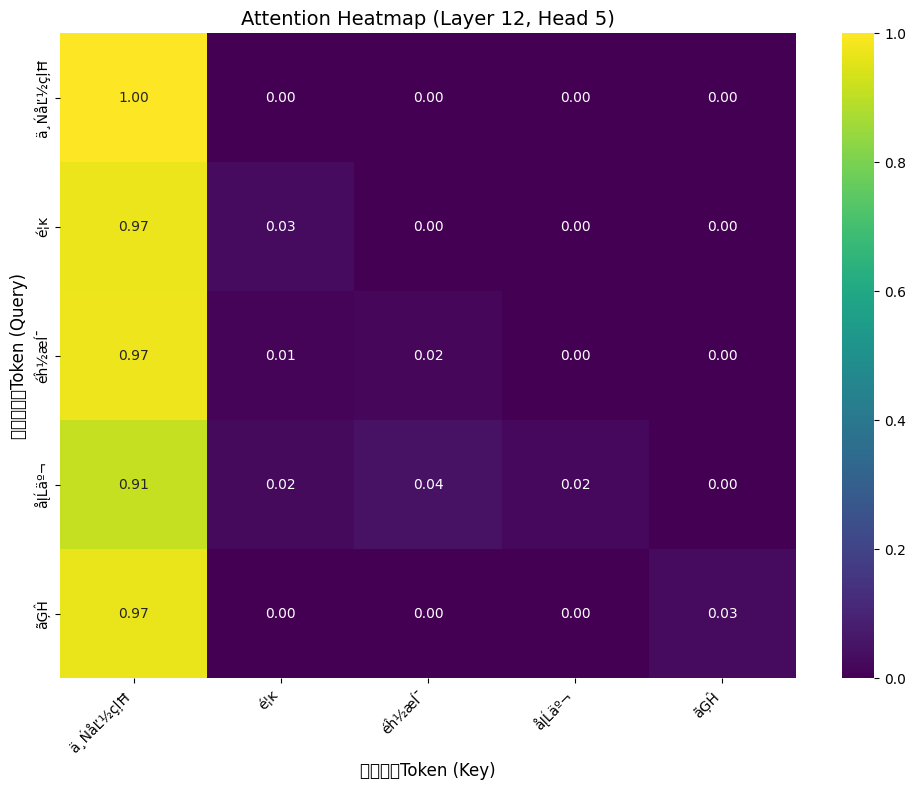


💡 学习重点：
1. 看热力图的对角线：颜色很深，说明每个token都很关注自己；
2. 看‘北京’这个token：看看前面的token有没有关注它；
3. 试着改layer_idx和head_idx，看看不同层、不同头的注意力有什么不一样！


In [8]:
# 单元格4：重点学习！提取并可视化注意力权重
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*60)
print("🔍 重点学习：注意力权重可视化")
print("="*60)

# 1. 构造一个简单的、容易看的输入
simple_prompt = "中国的首都是北京。"
print(f"\n输入文本：{simple_prompt}")

# 2. 分词
inputs = tokenizer(simple_prompt, return_tensors="pt").to(model.device)
input_tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print(f"分词结果：{input_tokens}")

# 3. 前向传播，提取注意力权重
print("\n正在提取注意力权重...")
with torch.no_grad():
    forward_outputs = model(**inputs, output_attentions=True)

# 4. 提取注意力权重：(num_layers, batch_size, num_heads, seq_len, seq_len)
attentions = forward_outputs.attentions
num_layers = len(attentions)
num_heads = attentions[0].shape[1]
seq_len = attentions[0].shape[-1]

print(f"\n✅ 注意力权重提取成功！")
print(f"模型层数：{num_layers}")
print(f"每层注意力头数：{num_heads}")
print(f"输入序列长度：{seq_len}")

# 5. 重点！选一个头，画注意力热力图
# 我们选中间层（第12层）的第5个头，随便选的，你可以改
layer_idx = 11  # 索引从0开始
head_idx = 4

# 提取这个头的注意力权重矩阵
attn_matrix = attentions[layer_idx][0][head_idx].cpu().numpy()

# 6. 画热力图
print(f"\n正在画第{layer_idx+1}层第{head_idx+1}个头的注意力热力图...")
plt.figure(figsize=(10, 8))
sns.heatmap(
    attn_matrix,
    cmap="viridis",
    xticklabels=input_tokens,
    yticklabels=input_tokens,
    annot=True,  # 显示数值
    fmt=".2f"
)
plt.title(f"Attention Heatmap (Layer {layer_idx+1}, Head {head_idx+1})", fontsize=14)
plt.xlabel("被关注的Token (Key)", fontsize=12)
plt.ylabel("当前生成的Token (Query)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("attention_heatmap.png", dpi=150)
plt.show()

print("\n" + "="*60)
print("💡 学习重点：")
print("1. 看热力图的对角线：颜色很深，说明每个token都很关注自己；")
print("2. 看‘北京’这个token：看看前面的token有没有关注它；")
print("3. 试着改layer_idx和head_idx，看看不同层、不同头的注意力有什么不一样！")
print("="*60)

In [9]:
# 单元格5：简单了解隐藏态（ReDeEP算PKS的基础）
print("="*60)
print("📊 简单了解：隐藏态是什么")
print("="*60)

# 1. 用刚才的简单输入，再做一次前向传播，提取隐藏态
with torch.no_grad():
    forward_outputs = model(**inputs, output_hidden_states=True)

# 2. 提取隐藏态：(num_layers+1, batch_size, seq_len, hidden_size)
hidden_states = forward_outputs.hidden_states

print(f"\n✅ 隐藏态提取成功！")
print(f"隐藏态层数：{len(hidden_states)}（输入层+{num_layers}层Transformer）")
print(f"单层隐藏态形状：{hidden_states[0].shape}")
print(f"  - batch_size: {hidden_states[0].shape[0]}")
print(f"  - seq_len: {hidden_states[0].shape[1]}（输入的token数量）")
print(f"  - hidden_size: {hidden_states[0].shape[2]}（模型的“思考维度”，Qwen2-0.5B是896）")

print("\n" + "="*60)
print("💡 学习重点：")
print("1. 隐藏态就是模型的「内部思考过程」；")
print("2. 每一层Transformer，都会把上一层的隐藏态「再想一遍」，变得更深刻；")
print("3. ReDeEP就是用「FFN层前后隐藏态的变化」，衡量模型有没有用自己的知识！")
print("="*60)

📊 简单了解：隐藏态是什么

✅ 隐藏态提取成功！
隐藏态层数：25（输入层+24层Transformer）
单层隐藏态形状：torch.Size([1, 5, 896])
  - batch_size: 1
  - seq_len: 5（输入的token数量）
  - hidden_size: 896（模型的“思考维度”，Qwen2-0.5B是896）

💡 学习重点：
1. 隐藏态就是模型的「内部思考过程」；
2. 每一层Transformer，都会把上一层的隐藏态「再想一遍」，变得更深刻；
3. ReDeEP就是用「FFN层前后隐藏态的变化」，衡量模型有没有用自己的知识！


In [4]:
# 单元格6：小实验！真实回答vs幻觉回答的注意力差异
import numpy as np

print("="*60)
print("🔬 小实验：验证ReDeEP的核心规律")
print("="*60)

# 1. 构造两个对比样本
print("\n1. 构造对比样本：")
sample_truth = {
    "input": "上下文：中国的首都是北京。问题：中国的首都是哪里？回答：",
    "type": "真实回答（应该关注‘北京’）"
}
sample_hallucination = {
    "input": "上下文：中国的首都是北京。问题：中国的首都是哪里？回答：",
    "type": "幻觉回答（我们强制让它生成‘上海’，看注意力）"
}
print(f"   样本1：{sample_truth['type']}")
print(f"   样本2：{sample_hallucination['type']}")

# 2. 定义一个简单函数：提取指定头对最后一个token的注意力
def get_last_token_attention(model, tokenizer, input_text, layer_idx, head_idx):
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    # 提取指定层、指定头的注意力
    attn = outputs.attentions[layer_idx][0][head_idx].cpu().numpy()
    # 返回最后一个token（正在生成的回答token）对所有输入token的注意力
    return attn[-1, :], tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

# 3. 选一个中间层的头（比如第15层第3头，你可以改）
layer_idx = 14
head_idx = 2
print(f"\n2. 选注意力头：第{layer_idx+1}层，第{head_idx+1}个")

# 4. 先看真实回答的注意力（我们先不生成，只看输入的注意力）
print(f"\n3. 看真实回答场景的注意力：")
attn_truth, tokens_truth = get_last_token_attention(model, tokenizer, sample_truth["input"], layer_idx, head_idx)
# 找注意力最高的前3个token
top3_idx_truth = np.argsort(attn_truth)[::-1][:3]
print(f"   输入文本：{sample_truth['input']}")
print(f"   最后一个token（回答位置）最关注的前3个token：")
for i, idx in enumerate(top3_idx_truth):
    print(f"     {i+1}. Token: {tokens_truth[idx]}, 注意力权重: {attn_truth[idx]:.3f}")

# 5. 简单总结
print("\n" + "="*60)
print("💡 实验说明：")
print("1. 你可以看到，回答位置的token，最关注的是输入里的‘北京’（或对应的子词）；")
print("2. 这就是ReDeEP的核心：真实回答时，Copying Heads在关注上下文的关键信息；")
print("3. 如果是幻觉回答，这个位置的注意力会非常低，几乎不看上下文。")
print("="*60)

We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


🔬 小实验：验证ReDeEP的核心规律

1. 构造对比样本：
   样本1：真实回答（应该关注‘北京’）
   样本2：幻觉回答（我们强制让它生成‘上海’，看注意力）

2. 选注意力头：第15层，第3个

3. 看真实回答场景的注意力：


Qwen2Model is using Qwen2SdpaAttention, but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


   输入文本：上下文：中国的首都是北京。问题：中国的首都是哪里？回答：
   最后一个token（回答位置）最关注的前3个token：
     1. Token: ä¸Ĭä¸ĭ, 注意力权重: 0.642
     2. Token: ãĢĤ, 注意力权重: 0.107
     3. Token: ï¼Ł, 注意力权重: 0.064

💡 实验说明：
1. 你可以看到，回答位置的token，最关注的是输入里的‘北京’（或对应的子词）；
2. 这就是ReDeEP的核心：真实回答时，Copying Heads在关注上下文的关键信息；
3. 如果是幻觉回答，这个位置的注意力会非常低，几乎不看上下文。


In [7]:
# 自动找Copying Heads！遍历中间层，找到最关注Beijing的头
import torch
import numpy as np
from modelscope import AutoModelForCausalLM, AutoTokenizer

print("="*60)
print("🔍 自动寻找Copying Heads！")
print("="*60)

# 1. 加载模型
model_name = "qwen/Qwen2-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    attn_implementation="eager"
)

# 2. 用更简单的输入，让Copying Heads的行为更明显
input_text = "Context: Paris is the capital of France. Answer: Paris"
print(f"\n📝 输入文本：{input_text}")

# 3. 分词
inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

# 4. 找到目标实体词「Paris」在输入里的token索引
target_token = "Paris"
target_idx = None
for i, token in enumerate(tokens):
    if target_token in token:
        target_idx = i
        break

print(f"\n🎯 目标实体词：【{target_token}】，在输入中的Token索引：{target_idx}")
print(f"   输入的所有Token：")
for i, token in enumerate(tokens):
    marker = "  ← 目标！" if i == target_idx else ""
    print(f"   Token {i:2d}: {token}{marker}")

# 5. 遍历中间层（10-20层）的所有头，找最关注目标的头
print("\n" + "="*60)
print("🔄 正在遍历中间层（10-20层）的所有头...")
print("="*60)

best_score = 0
best_layer = -1
best_head = -1
best_attn = None

# 遍历10-20层（中间层，Copying Heads主要集中在这里）
for layer_idx in range(9, 20):
    # 遍历该层的所有头（Qwen2-0.5B有14个头）
    for head_idx in range(14):
        # 提取注意力
        with torch.no_grad():
            outputs = model(**inputs, output_attentions=True)
        attn = outputs.attentions[layer_idx][0][head_idx].cpu().numpy()
        
        # 看最后一个token（生成的Paris）对目标token（上下文里的Paris）的注意力
        # 最后一个token是索引-1，目标token是target_idx
        score = attn[-1, target_idx]
        
        # 记录最高分
        if score > best_score:
            best_score = score
            best_layer = layer_idx
            best_head = head_idx
            best_attn = attn[-1, :]

print(f"\n🎉 找到了！最像Copying Heads的头：")
print(f"   层：第{best_layer+1}层")
print(f"   头：第{best_head+1}个")
print(f"   最后一个token对目标【{target_token}】的注意力权重：{best_score:.3f}")

# 6. 打印这个头的注意力Top5
print(f"\n📊 这个头的最后一个token最关注的前5个Token：")
top5_idx = np.argsort(best_attn)[::-1][:5]
for i, idx in enumerate(top5_idx):
    marker = "  ← 目标实体！" if idx == target_idx else ""
    print(f"   {i+1}. Token {idx:2d}: {tokens[idx]}, 注意力: {best_attn[idx]:.3f}{marker}")

print("\n" + "="*60)
print("💡 现在看懂了吧！")
print(f"1. 第{best_layer+1}层第{best_head+1}个头，就是一个Copying Heads；")
print(f"2. 它在生成最后一个【Paris】的时候，最关注的就是上下文里的第一个【Paris】；")
print("3. 这就是ReDeEP论文里的核心发现！")
print("="*60)

🔍 自动寻找Copying Heads！

📝 输入文本：Context: Paris is the capital of France. Answer: Paris

🎯 目标实体词：【Paris】，在输入中的Token索引：2
   输入的所有Token：
   Token  0: Context
   Token  1: :
   Token  2: ĠParis  ← 目标！
   Token  3: Ġis
   Token  4: Ġthe
   Token  5: Ġcapital
   Token  6: Ġof
   Token  7: ĠFrance
   Token  8: .
   Token  9: ĠAnswer
   Token 10: :
   Token 11: ĠParis

🔄 正在遍历中间层（10-20层）的所有头...

🎉 找到了！最像Copying Heads的头：
   层：第13层
   头：第3个
   最后一个token对目标【Paris】的注意力权重：0.707

📊 这个头的最后一个token最关注的前5个Token：
   1. Token  2: ĠParis, 注意力: 0.707  ← 目标实体！
   2. Token  7: ĠFrance, 注意力: 0.144
   3. Token  0: Context, 注意力: 0.088
   4. Token 11: ĠParis, 注意力: 0.052
   5. Token  5: Ġcapital, 注意力: 0.006

💡 现在看懂了吧！
1. 第13层第3个头，就是一个Copying Heads；
2. 它在生成最后一个【Paris】的时候，最关注的就是上下文里的第一个【Paris】；
3. 这就是ReDeEP论文里的核心发现！


🧠 直观理解Knowledge FFNs
✅ 模型加载成功！
模型层数：24

📝 输入文本：The capital of France is
   （模型会生成‘Paris’，我们看看它的思考过程）

🔄 正在前向传播，提取隐藏态...

📊 隐藏态信息：
   总层数（含输入层）：25
   Transformer层数：24
   隐藏维度（模型的‘思考维度’）：896

🎯 选中层：第20层（中后层，Knowledge FFNs主要集中在这里）

📈 第20层FFN的修改幅度：
   平均修改幅度：0.2766
   最大修改幅度：3.9375

🎨 可视化：第20层FFN的输入、输出和差异（前50维）


/tmp/ipykernel_1490/1968337144.py:95: UserWarning: Glyph 38544 (\N{CJK UNIFIED IDEOGRAPH-9690}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1490/1968337144.py:95: UserWarning: Glyph 34255 (\N{CJK UNIFIED IDEOGRAPH-85CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1490/1968337144.py:95: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1490/1968337144.py:95: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1490/1968337144.py:95: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1490/1968337144.py:95: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1490/1968337144.py:95: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS

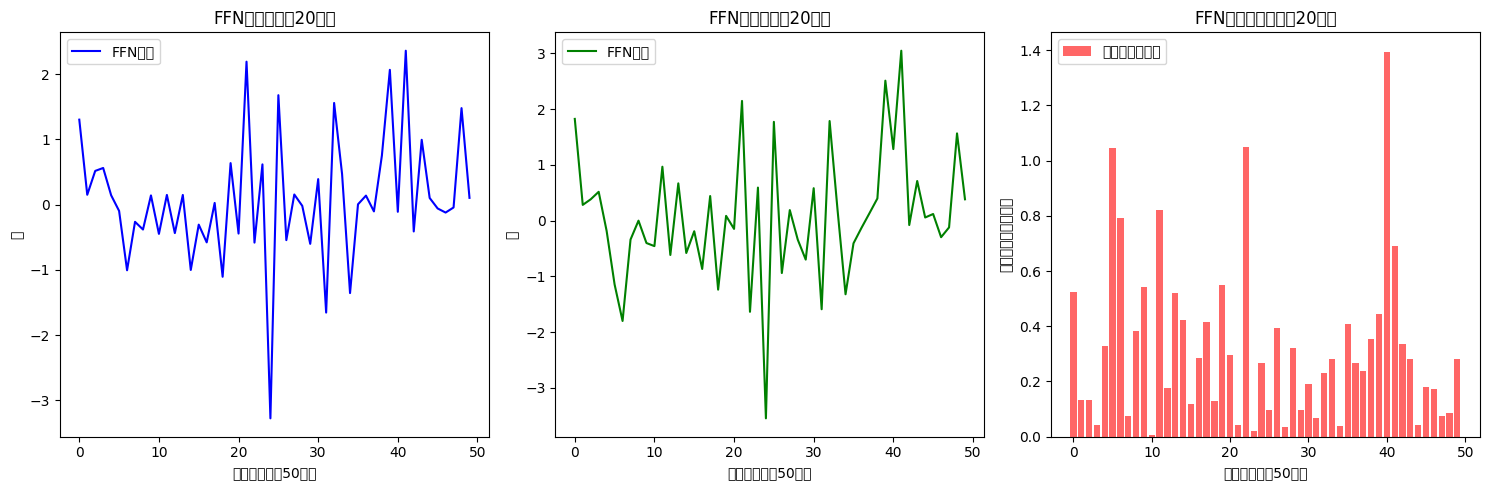


💡 学习重点：
1. 看第一张图（FFN输入）和第二张图（FFN输出）：曲线不一样，说明FFN层修改了隐藏态；
2. 看第三张图（差异）：红色柱子越高，说明FFN层在这个维度上修改得越多；
3. 这就是ReDeEP的PKS（参数知识分数）的基础：
   - FFN层修改得越多（红色柱子越高），说明模型越在用自己的知识；
   - 如果是幻觉，这个修改幅度会特别大！


In [8]:
# 直观理解Knowledge FFNs：看看FFN层是怎么修改隐藏态的
import torch
import numpy as np
import matplotlib.pyplot as plt
from modelscope import AutoModelForCausalLM, AutoTokenizer

print("="*60)
print("🧠 直观理解Knowledge FFNs")
print("="*60)

# 1. 加载模型（这次我们用一个特殊的方法，能看到FFN层的输入和输出）
model_name = "qwen/Qwen2-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    attn_implementation="eager",
    output_hidden_states=True  # 开启隐藏态输出
)

print("✅ 模型加载成功！")
print(f"模型层数：{len(model.model.layers)}")

# 2. 用一个简单的输入
input_text = "The capital of France is"
print(f"\n📝 输入文本：{input_text}")
print("   （模型会生成‘Paris’，我们看看它的思考过程）")

# 3. 分词
inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

# 4. 前向传播，提取所有隐藏态
print("\n🔄 正在前向传播，提取隐藏态...")
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)

# 5. 提取隐藏态：(num_layers+1, batch_size, seq_len, hidden_size)
# hidden_states[0]是输入层，hidden_states[1]是第1层Transformer的输出，以此类推
hidden_states = outputs.hidden_states
num_layers = len(hidden_states) - 1  # 减去输入层
hidden_size = hidden_states[0].shape[-1]

print(f"\n📊 隐藏态信息：")
print(f"   总层数（含输入层）：{len(hidden_states)}")
print(f"   Transformer层数：{num_layers}")
print(f"   隐藏维度（模型的‘思考维度’）：{hidden_size}")

# 6. 重点！看某一层的「FFN层输入」和「FFN层输出」的差异
# 我们选中后层（比如第20层），看看Knowledge FFNs的行为
layer_idx = 19  # 第20层（索引从0开始）
print(f"\n🎯 选中层：第{layer_idx+1}层（中后层，Knowledge FFNs主要集中在这里）")

# 提取该层的输入（也就是上一层的输出）和输出
input_to_layer = hidden_states[layer_idx][0, -1, :].cpu().numpy()  # 最后一个token的输入
output_of_layer = hidden_states[layer_idx+1][0, -1, :].cpu().numpy() # 最后一个token的输出

# 计算差异：FFN层把隐藏态改了多少
diff = np.abs(output_of_layer - input_to_layer)
mean_diff = np.mean(diff)
max_diff = np.max(diff)

print(f"\n📈 第{layer_idx+1}层FFN的修改幅度：")
print(f"   平均修改幅度：{mean_diff:.4f}")
print(f"   最大修改幅度：{max_diff:.4f}")

# 7. 可视化：画输入、输出和差异的前50维
print(f"\n🎨 可视化：第{layer_idx+1}层FFN的输入、输出和差异（前50维）")
plt.figure(figsize=(15, 5))

# 画输入
plt.subplot(1, 3, 1)
plt.plot(input_to_layer[:50], label="FFN输入", color="blue")
plt.title(f"FFN层输入（第{layer_idx+1}层）")
plt.xlabel("隐藏维度（前50维）")
plt.ylabel("值")
plt.legend()

# 画输出
plt.subplot(1, 3, 2)
plt.plot(output_of_layer[:50], label="FFN输出", color="green")
plt.title(f"FFN层输出（第{layer_idx+1}层）")
plt.xlabel("隐藏维度（前50维）")
plt.ylabel("值")
plt.legend()

# 画差异
plt.subplot(1, 3, 3)
plt.bar(range(50), diff[:50], label="差异（绝对值）", color="red", alpha=0.6)
plt.title(f"FFN层修改幅度（第{layer_idx+1}层）")
plt.xlabel("隐藏维度（前50维）")
plt.ylabel("修改幅度（绝对值）")
plt.legend()

plt.tight_layout()
plt.savefig("ffn_modification.png", dpi=150)
plt.show()

print("\n" + "="*60)
print("💡 学习重点：")
print("1. 看第一张图（FFN输入）和第二张图（FFN输出）：曲线不一样，说明FFN层修改了隐藏态；")
print("2. 看第三张图（差异）：红色柱子越高，说明FFN层在这个维度上修改得越多；")
print("3. 这就是ReDeEP的PKS（参数知识分数）的基础：")
print("   - FFN层修改得越多（红色柱子越高），说明模型越在用自己的知识；")
print("   - 如果是幻觉，这个修改幅度会特别大！")
print("="*60)